# <span style='color:deepskyblue'> Cosmology MCMC notebook </span>

## <span style='color:deepskyblue'>Preliminaries</span>

# Colsomology MCMC notebook (ΛCDM + SNIa)

## Aim
Use Type Ia supernova observations (Union2.1) to constrain ΛCDM parameters:
- $h$  dimensionless Hubble parameter
- $\Omega_m$ matter density
- $\Omega_\Lambda$ dark energy density


## We will do it this way:
1. Building $H(z)$, $d_L(z)$, and $\mu(z)$
2. Comparing $\mu_\text{theory}(z)$ to observed $\mu_\text{obs}(z)$ via $\chi^2$
3. Sampling the posterior probability using Metropolis-Hastings MCMC
4. Estimating best-fit values and uncertainties using GetDist

## Preliminaries


###Goal
 We need to set up the environment for cosmology calculatiions + Bayesian inference

###Implementation
We import number of numerical and plotting tools

In [1]:
# Install required packages (if not available on server, uncomment the lines below)

!pip3 install --upgrade pip
!pip3 install getdist # need this one to Analyze Monte Carlo Markov Chain (MCMC) samples
!pip3 install numpy
!pip3 install scipy
!pip3 install matplotlib



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 19.0 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 834.0/834.0 kB 6.9 MB/s  0:00:00


In [2]:
 #Load required packages
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import scipy.integrate as integrate

# import pylab
import getdist # cosmology/statistics library
import IPython, time
from numpy import random

# from IPython.display import Image
from getdist import plots, MCSamples, loadMCSamples
# MCSamples: A collection of Monte Carlo samples from a posterior distribution



# just for printing! calculations should be performed with machine precision
%precision 3

'%.3f'

(NB: Those equations that you will need to build your code are those $\boxed{\text{with a box around}}$)

## <span style='color:deepskyblue'> The $\Lambda$CDM Model </span>

The Lambda-Cold-Dark-Matter ($\Lambda$CDM) Model is our current "Standard" cosmological model. It postulates a Universe that behaves according to **General Relativity**, filled with **baryons** (protons, neutrons - the stuff we and stars are made of!), **Cold Dark Matter (CDM)** and a **Cosmological Constant** $\Lambda$.

The expansion of the Universe is best described in terms of the **scale factor** $a$ (the "radius" of the Universe, conventionally set to 1 today) and the **Hubble rate** $H$

$$
H \equiv \frac{\dot a}{a}
$$
Where the dot signifies a time derivative $\dot a \equiv da/dt $

The Einstein Equations in a **homogeneous and isotropic** Universe have an especially simple form and a special name, **Friedmann Equation**:

$$
H^2 = \frac{8\pi G}{3}\rho + \frac{k}{a^2}
$$

where $\rho$ is the total energy density of the Universe (at a certain time or size), and $k$ is a universal constant related to the [spatial curvature and shape of the Universe](https://en.wikipedia.org/wiki/Shape_of_the_universe#:~:text=The%20spatial%20curvature%20is%20related,indistinguishable%20spaces%20with%20different%20topologies.). In the $\Lambda$CDM model (and at late enough times), this additionally simplifies to

$$
\boxed{
H^2 = H_0^2\left(\Omega_\Lambda + \Omega_m a^{-3} + \Omega_k a^{-2}\right)
}
\qquad
\qquad
\boxed{
\Omega_m + \Omega_\Lambda + \Omega_k = 1
}
$$

$H_0$ is the value of the Hubble rate *today*, and the parameters $\Omega_m$, $\Omega_\Lambda$ and $\Omega_k$ are dimensionless quantities indicating how much of the present expansion of the Universe is due to (non-relativistic) matter, cosmological constant $\Lambda$, and spatial curvature $k$. Note that the three $\Omega$'s are *not independent* (their sum is 1) and that we grouped together the contribution of baryons and CDM,

$$
\Omega_m = \Omega_{\rm CDM} + \Omega_{\rm b}
$$

and that we have evidence that independent evidence that $\Omega_b \approx 5$\%. Note that only $\Omega_m \geq 0$ makes physical sense, while in principle both $\Omega_\Lambda$ and $\Omega_k$ can be negative.
In this consideration we are neglecting the contribution of the radiation which becomes negligable after the early stages of expansion.


The present Hubble rate is conventionally parametrised in terms of the dimensionless $h$:

$$
H_0 \equiv h\, \times 100 \left[\frac{ \,\text{km}}{\text{s Mpc}}\right]
$$

where Mpc = Megaparsec and [parsec](https://en.wikipedia.org/wiki/Parsec)  $pc = 3.086 \cdot 10^{16}$ m.

In essence, these equations give us the relation between *what exists in the Universe* and *how the Universe expanded*. Measure one, I can tell you the other. This is precisely what we aim to do!

Time to define the function $H(z)$. Don't forget to include the useful parameters as arguments of the function, and to define `parsec`.

## <span style='color:orange'> Excersise 1 </span>

Write your own code for the Hubble parameter as a function of redshift (z) note that $a = \frac{1}{1+z}$. Make a plot to see if your function works as expected.

## Implement and test of $H(z)$

### What we do
Implement a function `Hubble(z, H0, Omega_m, Omega_L, Omega_k)`.

### Why
We need $H(z)$ to compute the integral that defines the luminosity distance $d_L(z)$.

### Check
Plot $H(z)$ for typical parameters ($h=0.7,\Omega_m=0.3,\Omega_\Lambda=0.7$).
We expect a monotonically increasing curve with redshift.

## The ΛCDM expansion law and the Hubble function $H(z)$

The Friedmann equation in ΛCDM can be written as:

$$
H^2(z) = H_0^2\left(\Omega_\Lambda + \Omega_m (1+z)^3 + \Omega_k (1+z)^2\right),
\qquad \Omega_k = 1 - \Omega_m - \Omega_\Lambda
$$

Key physics:
- Matter density scales as $(1+z)^3$ due to volume dependence $a^{-3}$
- Curvature scales as  $(1+z)^2$
- Λ is constant in time

In [3]:
# Hubble rate
def Hubble(z, H0, Omega_m, Omega_L, Omega_k):
    return H0 * np.sqrt(
        Omega_L
        + Omega_m * (1 + z)**3
        + Omega_k * (1 + z)**2
    )



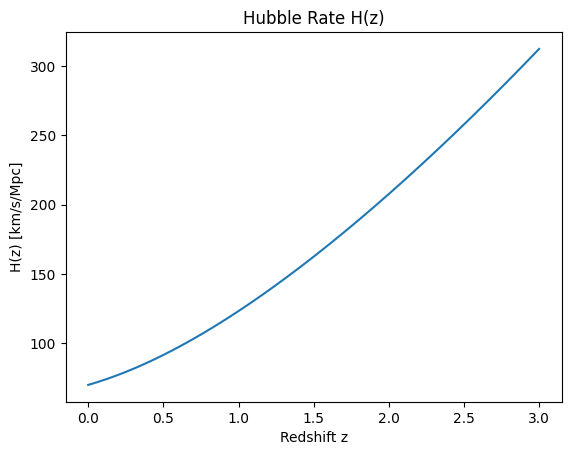

In [4]:
# Typical parameters
h = 0.7
H0 = 100 * h  # km/s/Mpc
Omega_m = 0.3
Omega_L = 0.7
Omega_k = 1.0 - Omega_m - Omega_L  # Flat universe

# Redshift range
z = np.linspace(0, 3, 500)

# Compute H(z)
Hz = Hubble(z, H0, Omega_m, Omega_L, Omega_k)

# Plot
plt.figure()
plt.plot(z, Hz)
plt.xlabel("Redshift z")
plt.ylabel("H(z) [km/s/Mpc]")
plt.title("Hubble Rate H(z)")
plt.show()

##  <span style='color:deepskyblue'>Supernovae Ia</span>

In order to track the expansion of the Universe, we will look at Supernovae type Ia observations. SNIa are formed when a *white dwarf* accretes matter from a companion until it reaches a critical mass of about $1.44 M_\odot$ (solar masses), after which it explodes **at always the same luminosity** $L_{\rm SN}$. Therefore, the observed [magnitude](https://en.wikipedia.org/wiki/Magnitude_(astronomy)) is only a function of their [**luminosity distance**](https://en.wikipedia.org/wiki/Distance_measures_(cosmology)) from Earth, defined as the ratio of the intrinsic luminosity $L_{\rm SNIa}$ and the measured *surface brightness* $\Phi$ (energy per unit time per unit area)

$$ d_L\equiv \frac{L_{\rm SN}}{4\pi \Phi} $$

While photons (light rays) travel from the distant SNIa to Earth, the Universe expands and the photons get redshifted, and this redshift is directly related to the size of the Universe when the photon was emitted compared to today:

$$ \frac{\lambda_{\rm obs}}{\lambda_{\rm em}} \equiv 1 + z_{\rm em} = \frac{1}{a_{\rm em}}$$

We can express the luminosity distance in terms of the Hubble rate:

$$
\boxed{
d_L(z) = \frac{c}{H_0}(1+z) \times
\begin{cases}
    \cfrac{1}{\sqrt{\Omega_k}} \,\sinh\left(\sqrt{\Omega_k}\,D(z)\right) & \Omega_k > 0
    \\[.5em]
    D(z) & \Omega_k = 0
    \\[.5em]
    \cfrac{1}{\sqrt{-\Omega_k}} \,\sin\left(\sqrt{-\Omega_k}\,D(z)\right) & \Omega_k < 0
\end{cases}
\qquad\qquad
D(z) \equiv H_0\int_0^z \frac{{\rm d}Z}{H(Z)}
}
$$

where $c$ is the speed of light: $c \simeq 2.998 \cdot 10^{5}$ km/s.

Clearly, there exists a relation between $d_L(z)$ and $H(z)$, so the luminosity distance is a useful measure of the Universe expansion history.

We can create the function `dL(z, h, Omega_m, Omega_Lambda)`. You can also pass the function `Hubble` as an argument: `dL(z, Hubble, Omega_m, Omega_Lambda)`. Additionally, you can create $D(z)$ for your convenience.

Note that you need to integrate the function $H(z)$, so write your own quick-and-easy numerical integrator, for example implementin the [trapezoidal rule](https://en.wikipedia.org/wiki/Trapezoidal_rule) or your favourite alternative, or [look up the pre-written methods](https://docs.scipy.org/doc/scipy/reference/tutorial/integrate.html). Make sure it returns $d_L$ in parsecs and that it uses $h$, which is $H_0$ measured in units of 100 km/s/Mpc!

## <span style='color:orange'> Excersise 2 </span>

Define a function that calculate the luminosty distance in flat ($\Omega_k = 0$) and both possitively and negatively curved  ($\Omega_k \neq 0$) spacetime.

## Supernovae Ia as standard candles and the luminosity distance $d_L(z)$


Type Ia supernovae have (approximately) the same intrinsic luminosity, so their observed brightness gives a distance. We use the same formula as was suggested above.



### Why numerical integration?
The integral over $1/H(z)$ generally has no simple closed form, so we approximate it numerically (trapezoidal rule).

### Check
$d_L(z)$ should increase with $z$. Curvature changes the shape slightly.

In [5]:


c = 2.998e5  # km/s

# helper function that will be used in luminosity_distance
def D_of_z(z, H0, Omega_m, Omega_L, Omega_k, n=1000): # use n = 1000 points to approximate the integral
    zs = np.linspace(0, z, n)     # linspace creates evenly spaced numbers between start = 0, stop = z
    Hz = Hubble(zs, H0, Omega_m, Omega_L, Omega_k)
    integral = np.trapz(1/Hz, zs) # computes a definite integral using a trapezoidal rule
    return H0 * integral



# implementation of the luminosity distance formula
def dL(z, h, Omega_m, Omega_Lambda):

    H0 = 100 * h
    Omega_k = 1.0 - Omega_m - Omega_Lambda

    D = D_of_z(z, H0, Omega_m, Omega_Lambda, Omega_k)

    if Omega_k > 0:
        Sk = np.sinh(np.sqrt(Omega_k) * D) / np.sqrt(Omega_k)
    elif Omega_k < 0:
        Sk = np.sin(np.sqrt(-Omega_k) * D) / np.sqrt(-Omega_k)
    else:
        Sk = D

    return (c / H0) * (1 + z) * Sk


/tmp/ipykernel_644/745050220.py:7: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(1/Hz, zs) # computes a definite integral using a trapezoidal rule


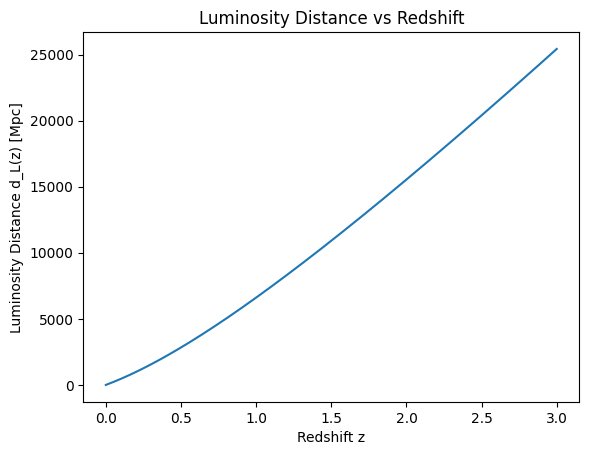

np.True_

In [6]:
# --- Check ---

z_vals = np.linspace(0, 3, 500)
h = 0.7
Omega_m = 0.3
Omega_Lambda = 0.7

dL_vals = np.array([dL(z, h, Omega_m, Omega_Lambda) for z in z_vals])

plt.figure()
plt.plot(z_vals, dL_vals)
plt.xlabel("Redshift z")
plt.ylabel("Luminosity Distance d_L(z) [Mpc]")
plt.title("Luminosity Distance vs Redshift")
plt.show()

np.all(np.diff(dL_vals) > 0)

## <span style='color:deepskyblue'>The Union2.1 Compilation</span>

Our source of data is from [Union2.1](http://supernova.lbl.gov/Union/). It is a collection of $580$ SNIa, each observation is comprised of redshift $z$ and [distance modulus](https://en.wikipedia.org/wiki/Distance_modulus) $\mu$ (and corresponding errors $\delta\mu$), defined as the difference between the *apparent magnitude* $m$ and the *absolute magnitude* $M$:

$$
\boxed{
\mu(z) \equiv m(z) - M \equiv 5 \log_{10} \frac{d_L(z)}{10\,\text{pc}}
}
$$

Our goal today is to use SNIa measurements to constrain the parameters ($h, \Omega_\Lambda, \Omega_m$).

In essence, we can calculate for each redshift the theoretical value of $\mu$ using this equation with the expression for $d_L(z)$ and our model of choice $H(z)$ -- note that we will need to perform a numerical integral! -- and compare this value with observations. A different model would amount to changing the theoretical value of $H(z)$.

Let us start by importing and plotting the data:

## Union2.1 Supernova data (z, μ, σ)

We load the Union2.1 compilation, which provides:
- redshift $z$
- observed distance modulus $\mu_\text{obs}$
- statistical and systematic uncertainties

We combine uncertainties via:
$
\sigma_\text{tot} = \sqrt{\sigma_\text{stat}^2 + \sigma_\text{sys}^2}
$

### Why μ?
Most supernova analyses are done in distance modulus:
$
\mu = 5\log_{10}\left(\frac{d_L}{10\,\text{pc}}\right)
$
because magnitudes are what is directly inferred from photometry.

In [7]:
import requests
import pandas as pd
import numpy as np
from io import StringIO # creates a file-like object from a string


# We have chosen slightly different library to implement the data loading

# URL
url = "https://supernova.lbl.gov/Union/figures/SCPUnion2.1_mu_vs_z.txt"

# Download
response = requests.get(url)
response.raise_for_status()  # stop if download failed

# Loading data
data = pd.read_csv(
    StringIO(response.text),
    delim_whitespace=True,
    comment='#',
    header=None
)


# Inspecting first rows
print(data.head())


        0         1          2         3         4
0  1993ah  0.028488  35.346583  0.223906  0.128419
1  1993ag  0.050043  36.682368  0.166829  0.128419
2   1993o  0.052926  36.817691  0.155756  0.128419
3   1993b  0.070086  37.446737  0.158467  0.128419
4  1992bs  0.062668  37.483409  0.156099  0.128419


/tmp/ipykernel_644/1896630892.py:17: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(


In [25]:
# Extract the redshifts (zs), distance modulus (dist_mod) and magnitude estimated errors (err_dist_mod)
# Data are in columns, so we either slice it by columns: arr[:,n]...
zs = data[:,1] # redshift
#print(len(zs))
# ...or transpose the array and then slice by row: arr_transposed[n]
distance_modulus = data.T[2] # distance modulus
error_distance_modulus = data.T[3] # errors on distance modulus = sigmas

In [8]:
# Column format:
# 0 = name
# 1 = redshift (z)
# 2 = distance modulus (mu)
# 3 = statistical error on mu
# 4 = systematic error on mu

zs = data.iloc[:, 1].to_numpy()              # redshift
distance_modulus = data.iloc[:, 2].to_numpy()  # mu
error_distance_modulus = data.iloc[:, 3].to_numpy()  # statistical error

# Optional: include systematic error as well
error_systematic = data.iloc[:, 4].to_numpy()

# Total uncertainty:
error_total = np.sqrt(error_distance_modulus**2 + error_systematic**2)

print("Number of supernovae:", len(zs))
print("First z:", zs[0])
print("First mu:", distance_modulus[0])
print("First sigma_stat:", error_distance_modulus[0])
print("First sigma_total:", error_total[0])

Number of supernovae: 580
First z: 0.028488
First mu: 35.3465833928
First sigma_stat: 0.223905932998
First sigma_total: 0.2581187547608394


In [9]:
# Let's look at the data, just for fun.
# We can look both at the raw data (distance modulus) or calculate the luminosity distance
# Note that Numpy allows us to manipulate whole arrays at once with something like:
#     array_2 = some_function_of(array_1)

# luminosity distance in pc
luminosity_distance_pc = 10. * 10.**(distance_modulus / 5.)

# and in Mpc
luminosity_distance_Mpc = luminosity_distance_pc / 10.**6

# and the error on that distance:
error_luminosity_distance_Mpc = 5. * (10.**((distance_modulus + error_distance_modulus)/5.-6.) - 10.**((distance_modulus - error_distance_modulus)/5.-6.))

Recommendation: plot the data so you can see the luminosity distance and distance modulus as a function of the redshift

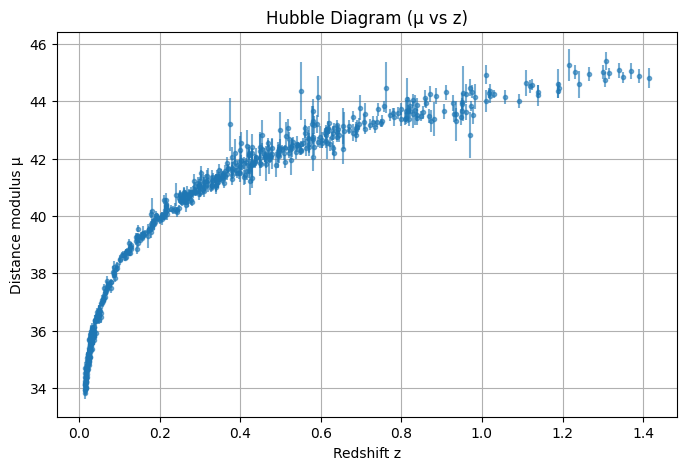

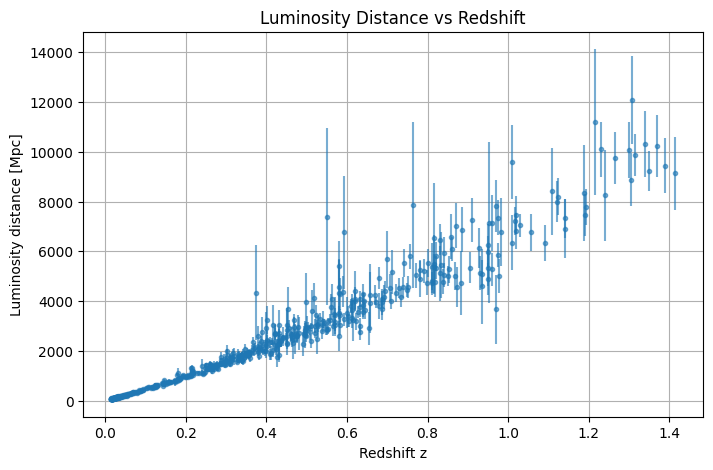

In [10]:
%matplotlib inline

import matplotlib.pyplot as plt

# --- Plot 1: Distance modulus vs redshift ---
plt.figure(figsize=(8,5))
plt.errorbar(zs, distance_modulus, yerr=error_distance_modulus,
             fmt='o', markersize=3, alpha=0.6)
plt.xlabel("Redshift z")
plt.ylabel("Distance modulus μ")
plt.title("Hubble Diagram (μ vs z)")
plt.grid(True)
plt.show()


# --- Plot 2: Luminosity distance vs redshift ---
plt.figure(figsize=(8,5))
plt.errorbar(zs, luminosity_distance_Mpc,
             yerr=error_luminosity_distance_Mpc,
             fmt='o', markersize=3, alpha=0.6)
plt.xlabel("Redshift z")
plt.ylabel("Luminosity distance [Mpc]")
plt.title("Luminosity Distance vs Redshift")
plt.grid(True)
plt.show()


## <span style='color:orange'> Excersise 3 </span>

Now also define a function to calculate the distance modulus using your previously defined luminosity distance function. Use these functions to plot the theoretical curves as a function of redshift and compare with the data. (Does the line go through the data points?)

In [11]:
# Just implementing the formulas provided before
def theor_distance_modulus(z, h=0.7, Omega_m=0.3, Omega_L=0.7):
    H0 = 100.0 * h
    Omega_k = 1.0 - Omega_m - Omega_L

    dL = np.array([
        luminosity_distance(zi, H0, Omega_m, Omega_L, Omega_k)
        for zi in np.atleast_1d(z)
    ])



    mu = 5.0 * np.log10(dL) + 25.0
    # If input was a scalar we return a scalar, otherwise we return an array
    # This was done for the function to act more predictable, that is input data
    # type corresponds to the output data type
    return mu if np.ndim(z) else float(mu[0])


Try your functions here. Make atleast two plots to check that for $\Omega_m = 0.3$, $\Omega_\Lambda = 0.7$ and $h =0.7$ your theory calculations of the luminosity distance and the distance modulus match okay to the data for redshifts ranging from ~0.1 to 2.

/tmp/ipykernel_644/745050220.py:7: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(1/Hz, zs) # computes a definite integral using a trapezoidal rule


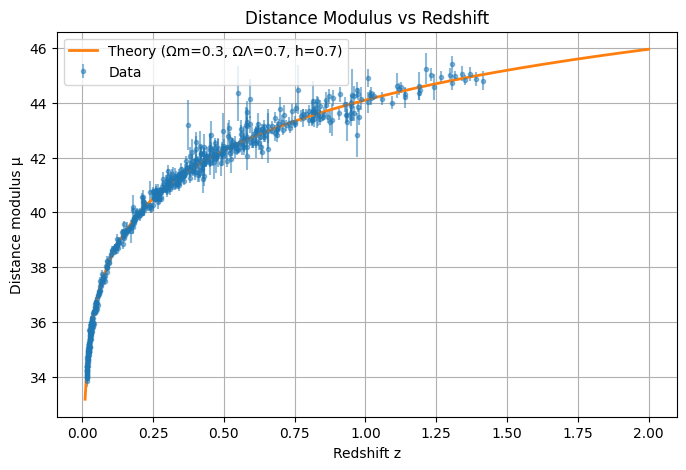

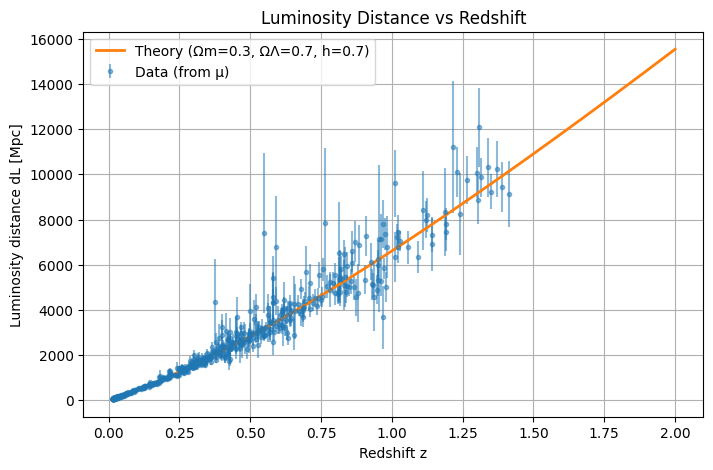

In [18]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt



# distance modulus from dL
def theor_distance_modulus(z, h=0.7, Omega_m=0.3, Omega_L=0.7):
    dL_vals = np.array([dL(zi, h, Omega_m, Omega_L) for zi in np.atleast_1d(z)])
    mu = 5.0 * np.log10(dL_vals) + 25.0
    return mu if np.ndim(z) else float(mu[0])


# Theory curves

zgrid = np.linspace(0.01, 2.0, 400)
mu_th = theor_distance_modulus(zgrid, h=0.7, Omega_m=0.3, Omega_L=0.7)
dL_th = np.array([dL(zi, 0.7, 0.3, 0.7) for zi in zgrid])  # Mpc


# Plot 1: distance modulus mu vs z

plt.figure(figsize=(8, 5))
plt.errorbar(zs, distance_modulus, yerr=error_distance_modulus,
             fmt='o', markersize=3, alpha=0.5, label="Data")
plt.plot(zgrid, mu_th, linewidth=2, label="Theory (Ωm=0.3, ΩΛ=0.7, h=0.7)")
plt.xlabel("Redshift z")
plt.ylabel("Distance modulus μ")
plt.title("Distance Modulus vs Redshift")
plt.grid(True)
plt.legend()
plt.show()



# Plot 2: luminosity distance dL vs z

plt.figure(figsize=(8, 5))
plt.errorbar(zs, luminosity_distance_Mpc, yerr=error_luminosity_distance_Mpc,
             fmt='o', markersize=3, alpha=0.5, label="Data (from μ)")
plt.plot(zgrid, dL_th, linewidth=2, label="Theory (Ωm=0.3, ΩΛ=0.7, h=0.7)")
plt.xlabel("Redshift z")
plt.ylabel("Luminosity distance dL [Mpc]")
plt.title("Luminosity Distance vs Redshift")
plt.grid(True)
plt.legend()
plt.show()

## <span style='color:deepskyblue'>Bayes' Theorem: Likelihood, Prior, Posterior (and Evidence...)</span>

The **conditional probability of A given that B is true** is denoted with $P(A|B)$ (read: *probability of A given B*).
Did A happen? Then B has probability $P(B|A)$ of happening.

[**Bayes' Theorem**](https://en.wikipedia.org/wiki/Bayes%27_theorem) is simply a reflection of the symmetry of the concept of joint probability:

$$
P(A|B)P(B) = P(B|A)P(A)
$$

In physics, our goal is often to determine how likely the values of some parameters $\theta$ are, given how well they reproduce the data $D$.
We write Bayes' theorem in the following equivalent form:

$$
P(\theta | D) = \frac{P(D|\theta)P(\theta)}{P(D)}
$$

The various terms conventionally take the names:

$$
\begin{aligned}
P(\theta | D) & && \text{Posterior}
\\
P(D | \theta)& && \text{Likelihood}
\\
P(\theta) & && \text{Prior}
\\
P(D) & && \text{Evidence}
\end{aligned}
$$

### <span style='color:deepskyblue'>Prior</span>

The *prior* quantifies our degree of prior belief in the model parameters. It can contain the results of previous experiments, or theoretical considerations (for instance, that certain parameters cannot be negative, etc.).

We can have *strong priors* about something - the Sun still existing at night, see the comic below - or not.
When we do *not* have compelling prior knowledge about a parameter, we generally use a *non-informative* prior probability distribution, most often related to the [uniform distribution](https://en.wikipedia.org/wiki/Continuous_uniform_distribution)

$$
\begin{aligned}
    \text{Uniform} & && \theta \in \text{Uniform}[\theta_{\rm min}, \theta_{\rm max}]
    \\
    \text{Log Uniform} & && \log\theta \in \text{Uniform}[\log\theta_{\rm min}, \log\theta_{\rm max}]
\end{aligned}
$$

You may sometimes hear that "the prior doesn't matter". While this is not strictly true, it is however true that in many instances the *likelihood* depends more dramatically on the parameters and will have a dominating contribution to the posterior. You are more than welcome to try different priors for the model parameters and see if and how your results change.

### <span style='color:deepskyblue'>Likelihood</span>

The measure of how well our model reproduces the data is the **likelihood** $\mathcal L$. For normal (=Gaussian), uncorrelated data $\mu_i$ with errors $\sigma_i$ ($i = \{1,580\}$), the likelihood is related to the famous [**chi-squared**](https://en.wikipedia.org/wiki/Chi-square_distribution) via

$$
P(D | \theta) \equiv \mathcal L = \exp\left(-\frac{\chi^2}{2}\right)
\qquad
\qquad
\boxed{
\chi^2 \equiv \sum_{i=1}^{580} \frac{\left(\mu_i^{(\rm theor)} - \mu_i^{(\rm obs)}\right)^2}{\sigma_i^2}
}
$$

A *high likelihood* corresponds to a *low chi squared*.

In principle, we could attack the problem brute-force: create a grid of values for $h$, $\Omega_m$, $\Omega_\Lambda$, calculate the likelihood for each combination, and create a profile for the likelihood.

In practical cases, however, this is not only sub-optimal but sometimes **impossible**. Think of complicated models with 20+ free parameters (this is not that unusual in physics, by the way). Even a very coarse grained grid of 100 values for each parameter would result in more than$10^{40}$ (!!!) different parameter combination to be tested. You can probably understand why this is undesirable.

### <span style='color:deepskyblue'>Evidence</span>

This is the tricky bit. The evidence, which is "*the probability of observing certain data*", is not something that is easy to evaluate or interpret. This looks like a serious limitation to finding the:


### <span style='color:deepskyblue'>Posterior</span>

What does the data tell us about the model parameters? The answer is the *posterior probability distribution*, often (but not necessarily) expressed as (average $\pm$ standard deviation)

$$
\theta_i = \bar\theta_i \pm \sigma_i
$$

In other words, the posterior tells us how likely it is for the model parameters to have certain values, *given that we observe the data* $D$.

*This is the final goal of our analysis!*

<br>

![title](http://1.bp.blogspot.com/-tTx4HDejSww/ULcTeK9_V_I/AAAAAAAAA8g/PCYOH-eXGbk/s1600/frequentists_vs_bayesians.png)
![title](https://i.redd.it/5r0hwixt0m931.jpg)

## <span style='color:deepskyblue'>Markov-Chain Monte Carlo</span>

Markov-Chain Monte Carlo techniques are a class of methods to sample a probability distribution $P(x)$ - in our case $P(\theta | D)$ - provided that we can calculate a density $\mathcal F(x)$ **that is proportional to it** - in our case $P(\theta)P(D|\theta)$ = likelihood $\times$ prior. Among these, a very popular one is the [**Metropolis-Hastings**](https://en.wikipedia.org/wiki/Metropolis%E2%80%93Hastings_algorithm) algorithm, which is what we will use.

Schematically, the algorithm works as follows:
* Start with an $n$-tuple of parameters $\theta_{\rm old} = \{\theta_1, \theta_2, \dots\}_{\rm old}$ (in our case $\theta = \{h,\Omega_m,\Omega_\Lambda\}$) and calculate the $\mathcal F_{\rm old}$
* Propose a new set of parameters $\theta_{\rm prop}$, calculate the new corresponding $\mathcal F_{\rm prop}$. How you propose the new parameters is not essential as long as the probability of going from one set of parameters to the next is the same as the inverse: $P(\theta_a \to \theta_b) = P(\theta_b \to \theta_a)$. For this, we normally take Gaussian displacements with some (relatively small) standard deviation.
* Compare the new and old likelihoods-priors:
    * If $\mathcal F_{\rm prop} > \mathcal F_{\rm old}$, accept the step: $\theta_{\rm new} = \theta_{\rm prop}$
    * Otherwise, accept with probability $P_{\rm accept} = \mathcal F_{\rm prop}/\mathcal F_{\rm old}$
* If accepted, $\theta_{\rm new} = \theta_{\rm prop}$ and record the step; otherwise, $\theta_{\rm new} = \theta_{\rm old}$ (no re-recording)
* Update $\theta_{\rm old} = \theta_{\rm new}$
* Repeat

The MC chain keeps going until the desired number of steps or, ideally, when a suitable convergence test, like for example the [Gelman-Rubin test](https://bookdown.org/rdpeng/advstatcomp/monitoring-convergence.html), is satisfied.
Today we will just set a limit to the total number of steps, but please feel free to implement and test your favourite convergence test!

Looking at equation (4), you can convince yourself that
$$
\frac{\mathcal L_a}{\mathcal L_b} = \exp\left(\frac{\chi_b^2 - \chi_a^2}{2}\right)
$$

(This is useful because $\chi^2$ can be large, so we want to avoid the likelihoods evaluating to `0.` -- computers don't like dividing by zero, unfortunately)

* Start with an $n$-tuple of parameters $\theta_{\rm old} = \{\theta_1, \theta_2, \dots\}_{\rm old}$ (in our case $\theta = \{h,\Omega_m,\Omega_\Lambda\}$) and the corresponding chi squared $\chi_{\rm old}^2$ (to be clear, for us this implies calculating a series of 580 integrals and comparing each with the observed values)
* Propose new parameters $\theta_{\rm prop}$ and calculate the corresponding chi squared $\chi_{\rm prop}^2$
* Draw a random number $r \in [0,1]$
* Accept the step if
$$
r < \exp\left(\frac{\chi_{\rm old}^2 - \chi_{\rm prop}^2}{2}\right) \frac{P(\theta)_{\rm prop}}{P(\theta)_{\rm old}}
$$
* If accepted, update $\theta_{\rm old} = \theta_{\rm prop}$, and record; otherwise, $\theta_{\rm new} = \theta_{\rm old}$ (no re-recording)
* Repeat

##  <span style='color:orange'> Excersise 4 </span>

Write your own code to perform a Monte Carlo Markov Chain. Note that your algorithm should be robust and converge to the correct parameters even for poor initial guesses.

## Exercise 4 — MCMC for ΛCDM parameter estimation

The goal of this exercise is to determine the best-fitting cosmological parameters
$
(h, \Omega_m, \Omega_\Lambda)
$
from the supernova data.

---

### Step 1 — Build a function that evaluates the model

First, I implement a function that:

- takes a parameter set $ (h, \Omega_m, \Omega_\Lambda) $
- computes the theoretical distance modulus $ \mu_{\rm th}(z) $
- compares it to the observed data
- returns the corresponding goodness-of-fit value $ \chi^2 $

This gives me a way to measure how good any parameter choice is. Smaller $ \chi^2 $ means better agreement with the data.

---

### Step 2 — Explore parameter space with MCMC

Instead of scanning all possible parameter combinations (which would be inefficient),
I use a **Metropolis–Hastings Markov Chain**.

The algorithm works as follows:

1. Start from an initial guess (even a poor one).
2. Propose a small random change in the parameters.
3. Compute the new $ \chi^2 $.
4. Accept the new parameters if:
   - they improve the fit, or  
   - they worsen it only slightly with probability:    $  \exp\left[-\frac{1}{2}(\chi^2_{\rm new}-\chi^2_{\rm old})\right] $

This procedure ensures that:
- the chain naturally moves toward better-fitting regions,
- but still explores the surrounding parameter space.

---

### Step 3 — Convergence and sampling

After an initial “burn-in” phase (where the chain forgets the bad starting point),
I keep thinned samples of the parameters.

The distribution of these kept samples approximates the posterior probability $
P(h, \Omega_m, \Omega_\Lambda \mid \text{data})
$




In [33]:
import numpy as np
import time
from random import random, gauss

c = 2.998e5  # km/s


# Precompute integration grid once (covers your data range)

zmax = float(np.max(zs))
N_int = 2000  # increase for accuracy, decrease for speed
z_grid = np.linspace(0.0, zmax, N_int)
dz = z_grid[1] - z_grid[0]


# mu(z) vectorized + interpolation

def mu_theory_for_data(z_data, h, Omega_m, Omega_L):
    """
    Returns mu_theory evaluated at z_data (array), using a single z_grid integral + interpolation.
    Returns None for unphysical/invalid parameter choices.
    """
    # basic physical constraints
    if h <= 0 or Omega_m < 0 or Omega_L < 0:
        return None

    H0 = 100.0 * h
    Omega_k = 1.0 - Omega_m - Omega_L

    # keeping curvature in a reasonable range (prevents chain wandering into extreme Ωk)
    if abs(Omega_k) > 1.0:
        return None

    # E(z) = H(z)/H0
    Ez = np.sqrt(Omega_L + Omega_m * (1.0 + z_grid) ** 3 + Omega_k * (1.0 + z_grid) ** 2)
    if np.any(~np.isfinite(Ez)) or np.any(Ez <= 0):
        return None

    invE = 1.0 / Ez

    # Dimensionless comoving distance: D(z) = ∫0^z dz'/E(z') via cumulative trapezoid
    D_grid = np.zeros_like(z_grid)
    D_grid[1:] = np.cumsum(0.5 * (invE[1:] + invE[:-1]) * dz)

    # Interpolate D(z) at the supernova redshifts
    D = np.interp(z_data, z_grid, D_grid)



    # Curvature-dependent transverse comoving distance factor S_k(D)
    if Omega_k > 0:
        sqrtOk = np.sqrt(Omega_k)
        Sk = np.sinh(sqrtOk * D) / sqrtOk
    elif Omega_k < 0:
        sqrtOk = np.sqrt(-Omega_k)
        Sk = np.sin(sqrtOk * D) / sqrtOk
    else:
        Sk = D

    # Luminosity distance in Mpc: dL = (c/H0) (1+z) S_k(D)
    dL_Mpc = (c / H0) * (1.0 + z_data) * Sk
    if np.any(dL_Mpc <= 0) or np.any(~np.isfinite(dL_Mpc)):
        return None

    # Distance modulus: mu = 5 log10(dL[Mpc]) + 25
    return 5.0 * np.log10(dL_Mpc) + 25.0


def chi2(h, Omega_m, Omega_L):
    mu_th = mu_theory_for_data(zs, h, Omega_m, Omega_L)
    if mu_th is None:
        return np.inf
    return np.sum(((mu_th - distance_modulus) / error_total) ** 2)







# MCMC (Metropolis-Hastings)

# Settings
N_steps = 20000
burn_in = 2000
thin = 5

# Proposal widths (tune if needed)
step_Om = 0.02
step_OL = 0.02
step_h  = 0.01

# Initial guess (can be "bad" on purpose)
Omega_m = 0.9
Omega_L = 0.1
h = 0.9

chi2_old = chi2(h, Omega_m, Omega_L)

accepted = 0
kept = 0

# Store kept samples here
kept_Om = []
kept_OL = []
kept_h  = []
kept_chi2 = []

print("Progress:")
start = time.time()

for i in range(N_steps):
    Om_prop = Omega_m + gauss(0, step_Om)
    OL_prop = Omega_L + gauss(0, step_OL)
    h_prop  = h       + gauss(0, step_h)

    chi2_prop = chi2(h_prop, Om_prop, OL_prop)

    dchi2 = chi2_prop - chi2_old
    accept_prob = np.exp(-0.5 * dchi2) if np.isfinite(chi2_prop) else 0.0

    if (chi2_prop < chi2_old) or (random() < accept_prob):
        Omega_m, Omega_L, h = Om_prop, OL_prop, h_prop
        chi2_old = chi2_prop
        accepted += 1

    # keep thinned samples after burn-in
    if i >= burn_in and (i - burn_in) % thin == 0:
        kept_Om.append(Omega_m)
        kept_OL.append(Omega_L)
        kept_h.append(h)
        kept_chi2.append(chi2_old)
        kept += 1

    if (i + 1) % 2000 == 0:
        Omega_k_cur = 1.0 - Omega_m - Omega_L
        print(f"  step {i+1}/{N_steps}, Om={Omega_m:.3f}, OL={Omega_L:.3f}, Ok={Omega_k_cur:.3f}, h={h:.3f}, chi2={chi2_old:.1f}")

end = time.time()

# Convert lists to numpy arrays for the next cell (GetDist)
kept_Om = np.array(kept_Om)
kept_OL = np.array(kept_OL)
kept_h  = np.array(kept_h)
kept_chi2 = np.array(kept_chi2)

print("Acceptance ratio =", accepted / N_steps)
print("Samples kept =", kept)
print("time required: {:.2f} s".format(end - start))

Progress:
  step 2000/20000, Om=0.136, OL=0.619, Ok=0.246, h=0.701, chi2=214.6
  step 4000/20000, Om=0.279, OL=0.820, Ok=-0.099, h=0.698, chi2=215.4
  step 6000/20000, Om=0.341, OL=0.794, Ok=-0.135, h=0.691, chi2=219.0
  step 8000/20000, Om=0.299, OL=0.658, Ok=0.043, h=0.694, chi2=217.6
  step 10000/20000, Om=0.319, OL=0.942, Ok=-0.261, h=0.708, chi2=215.5
  step 12000/20000, Om=0.130, OL=0.593, Ok=0.277, h=0.699, chi2=214.5
  step 14000/20000, Om=0.385, OL=1.035, Ok=-0.420, h=0.714, chi2=219.2
  step 16000/20000, Om=0.313, OL=0.854, Ok=-0.167, h=0.704, chi2=214.4
  step 18000/20000, Om=0.169, OL=0.606, Ok=0.226, h=0.702, chi2=215.1
  step 20000/20000, Om=0.139, OL=0.484, Ok=0.377, h=0.696, chi2=216.1
Acceptance ratio = 0.4041
Samples kept = 3600
time required: 5.71 s


In [34]:
for N in [500, 1000, 2000, 5000]:
    N_int = N
    z_grid = np.linspace(0.0, float(np.max(zs)), N_int)
    dz = z_grid[1] - z_grid[0]
    print(N, chi2(0.7, 0.3, 0.7))

500 216.98546011035756
1000 216.98562351738977
2000 216.9857082381447
5000 216.98550688722088


After completion of the programme, your MC chain will (*hopefully*) look something like this:

`#Omega_m  Omega_L  h`

`0.297     0.703    0.698`

`0.285     0.715    0.701`

`0.288     0.712    0.699`

`...`

## <span style='color:deepskyblue'>Plotting: GetDist</span>

We will do the plots with [`GetDist`](https://getdist.readthedocs.io/en/latest/plot_gallery.html).

The plot gallery contains a lot of useful examples, you should be able to read them fairly easily and see which applies to your situation. Look for both (triangle) plots and for parameter estimation.

Note that many `GetDist` functions require arguments of type `MCSamples`; make sure you convert your lists accordingly.

##  <span style='color:orange'> Excersise 5 </span>

Use the GetDist functions in the example given underneath but with your **own** MCMC data to generate investigate the sampling of the MCMC.

## Implementation

The following code takes the stored MCMC samples and combines them into a single 2D array so they can be analyzed with GetDist. It removes an additional fraction of early samples to ensure that only the converged part of the chain is used. From the sampled parameters $\Omega_m$ and $\Omega_\Lambda$, it computes the derived curvature parameter $\Omega_k$. The cleaned samples are then converted into an MCSamples object, which allows GetDist to compute statistical quantities such as 68\% confidence intervals. Finally, it produces a triangle plot showing the marginalized distributions and correlations between $h$, $\Omega_m$, $\Omega_\Lambda$, and $\Omega_k$.

samples shape: (2520, 4)
Removed no burn in
0.694 < h < 0.706 at 68% CL
0.117 < OmegaM < 0.330 at 68% CL
0.512 < OmegaL < 0.877 at 68% CL
-0.201 < Omegak < 0.359 at 68% CL


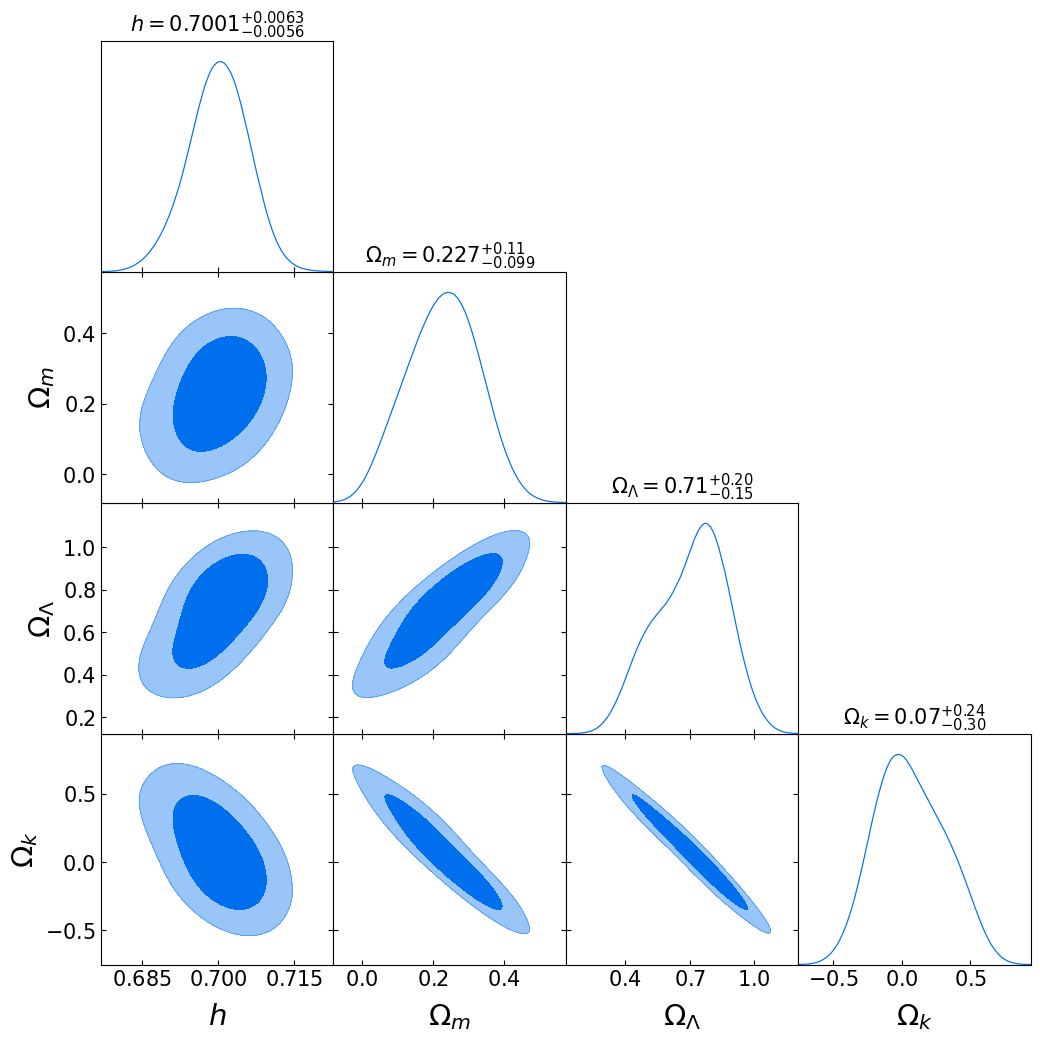

In [35]:
import numpy as np
from getdist import MCSamples, plots


# Build the same "datafile" structure the txt file used to contain: [Om, OL, h, chi2]
datafile = np.column_stack([kept_Om, kept_OL, kept_h, kept_chi2])

# If it's empty, fail loudly with a helpful message
if datafile.size == 0:
    raise ValueError("In-memory chain is empty. Check that your MCMC stored samples (kept_*)")

# Ensure 2D even if there's only 1 row
datafile = np.atleast_2d(datafile)

# Burn-in as a fraction of the *saved* chain length
burn_frac = 0.3
burn = int(burn_frac * len(datafile))
chain = datafile[burn:, :]

# Columns: Om, OL, h, chi2
OmegaM = chain[:, 0]
OmegaL = chain[:, 1]
h      = chain[:, 2]
chi2   = chain[:, 3]

Omegak = 1.0 - OmegaM - OmegaL

# GetDist setup
my_labels = [r'h', r'\Omega_m', r'\Omega_\Lambda', r'\Omega_k']
my_names  = ['h', 'OmegaM', 'OmegaL', 'Omegak']

samples_arr = np.column_stack([h, OmegaM, OmegaL, Omegak])
print("samples shape:", samples_arr.shape)

my_samples = MCSamples(samples=samples_arr, labels=my_labels, names=my_names)

# 68% intervals
conf_level = 0.6827
for nam in my_names:
    lo = my_samples.confidence(nam, (1.0 - conf_level)/2.0, upper=False)
    hi = my_samples.confidence(nam, (1.0 - conf_level)/2.0, upper=True)
    print(f"{lo:.3f} < {nam} < {hi:.3f} at {int(100*conf_level)}% CL")

# Triangle plot
g = plots.get_subplot_plotter(subplot_size=3)
g.settings.axes_labelsize = 22
g.settings.axes_fontsize = 16
g.triangle_plot(my_samples, filled=True, title_limit=1)

In [36]:
print(my_samples.getParamNames())

h	h
OmegaM	\Omega_m
OmegaL	\Omega_\Lambda
Omegak	\Omega_k



##  <span style='color:orange'> Excersise 6 </span>

Show the curves for $d_L$ and/or $\mu$ as a function of redshift using the best fit parameters determined using your MCMC code, so you will need to make use of your earlier defined functions for $d_L$ and $\mu$ . Check if this correctly reproduces the data. Additionally, provide an extimate on the error and plot the corresponding confidence intervals based on the sample that your MCMC code produces.

## Implementation

This code first selects `best-fit' cosmological parameters from the MCMC results, either by taking the posterior median values from the MCSamples object or by choosing the single saved sample with the minimum $\chi^2$. It then builds a smooth redshift grid and defines a helper function that computes the luminosity distance $d_L(z)$ and the corresponding distance modulus $\mu(z)$ for any parameter choice. Using the best-fit parameters, it evaluates theoretical curves $d_L(z)$ and $\mu(z)$ across the redshift grid. Next, it plots the observed supernova distance moduli (with error bars) together with the theoretical best-fit $\mu(z)$ curve for visual comparison. Finally, it converts the observed distance moduli into $d_L$ values and plots those against the theoretical best-fit $d_L(z)$ curve, using logarithmic scales to clearly display the wide range of redshift and distance values.

Best (median): 0.7001904101458082 0.23045394682497528 0.7312995577438294
Best (min chi2): 0.7016207451031778 0.2497959008772558 0.76770932510983


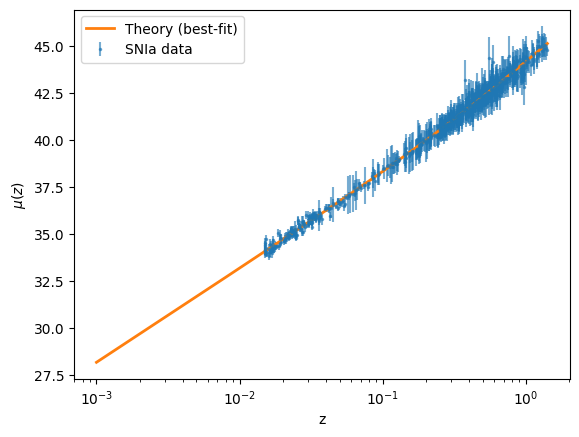

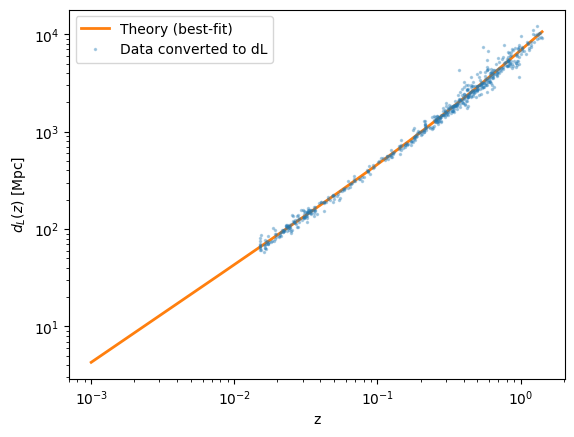

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1) Choose "best-fit" parameters from MCMC samples ---

# Option A (recommended): posterior median (robust)
h_best      = my_samples.confidence('h',      0.5)
Omega_M_best= my_samples.confidence('OmegaM', 0.5)
Omega_L_best= my_samples.confidence('OmegaL', 0.5)

# Option B: min chi2 sample from your saved chain (often similar)
# (Only works if you still have the arrays OmegaM, OmegaL, h, chi2 from loading the file)
idx_best = np.argmin(chi2)
h_best_chi2       = h[idx_best]
Omega_M_best_chi2 = OmegaM[idx_best]
Omega_L_best_chi2 = OmegaL[idx_best]

print("Best (median):", h_best, Omega_M_best, Omega_L_best)
print("Best (min chi2):", h_best_chi2, Omega_M_best_chi2, Omega_L_best_chi2)


# --- 2) Compute d_L(z) and mu(z) on a z grid using best-fit params ---

# Build a smooth z grid for plotting theory curves
z_plot = np.linspace(0.001, np.max(zs), 400)

# We'll reuse the fast grid-integral+interp approach but return dL and mu.
# (This is basically your mu_theory_for_data, but also returns dL.)
c = 2.998e5  # km/s

def dL_and_mu(z_data, h, Omega_m, Omega_L, N_int=2000):
    H0 = 100.0 * h
    Omega_k = 1.0 - Omega_m - Omega_L

    zmax = float(np.max(z_data))
    z_grid = np.linspace(0.0, zmax, N_int)
    dz = z_grid[1] - z_grid[0]

    Ez = np.sqrt(Omega_L + Omega_m * (1.0 + z_grid)**3 + Omega_k * (1.0 + z_grid)**2)
    invE = 1.0 / Ez

    # cumulative trapezoid for D(z) = ∫ dz/E(z)
    D_grid = np.zeros_like(z_grid)
    D_grid[1:] = np.cumsum(0.5 * (invE[1:] + invE[:-1]) * dz)
    D = np.interp(z_data, z_grid, D_grid)

    if Omega_k > 0:
        sqrtOk = np.sqrt(Omega_k)
        Sk = np.sinh(sqrtOk * D) / sqrtOk
    elif Omega_k < 0:
        sqrtOk = np.sqrt(-Omega_k)
        Sk = np.sin(sqrtOk * D) / sqrtOk
    else:
        Sk = D

    dL_Mpc = (c / H0) * (1.0 + z_data) * Sk
    mu = 5.0 * np.log10(dL_Mpc) + 25.0
    return dL_Mpc, mu

# Theory curves using median best-fit
dL_best, mu_best = dL_and_mu(z_plot, h_best, Omega_M_best, Omega_L_best)


# --- 3) Plot data vs theory ---

# Plot distance modulus μ(z)
plt.figure()
plt.errorbar(zs, distance_modulus, yerr=error_total, fmt='.', markersize=3, alpha=0.6, label='SNIa data')
plt.plot(z_plot, mu_best, linewidth=2, label='Theory (best-fit)')
plt.xlabel("z")
plt.ylabel(r"$\mu(z)$")
plt.legend()
plt.xscale("log")  # optional: log x often looks nicer for SNIa
plt.show()

# Plot luminosity distance d_L(z)
plt.figure()
plt.errorbar(zs, 10**((distance_modulus - 25)/5), yerr=None, fmt='.', markersize=3, alpha=0.3, label='Data converted to dL')
plt.plot(z_plot, dL_best, linewidth=2, label='Theory (best-fit)')
plt.xlabel("z")
plt.ylabel(r"$d_L(z)$ [Mpc]")
plt.legend()
plt.xscale("log")
plt.yscale("log")  # dL spans orders of magnitude, log-log is common
plt.show()